In [1]:

# CELDA 1: CARGA DE DATOS ETIQUETADOS DESDE PARQUET

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
import os

# Inicializamos la sesión de Spark
spark = SparkSession.builder \
    .appName("ModelosSupervisadosInmobiliaria") \
    .getOrCreate()

# Ruta donde guardamos nuestros datos etiquetados en la sesión anterior
ruta_parquet = "modelos/datos_etiquetados_kmeans"

print("Cargando datos etiquetados desde Parquet...")
df_supervisado = spark.read.parquet(ruta_parquet)

# Mostramos un adelanto para asegurar que cargó bien la columna 'prediction'
df_supervisado.select("precio_num", "dormitorios_num", "banos_num", "IDH", "prediction").show(5)
print(f"Registros totales cargados para entrenamiento: {df_supervisado.count()}")

Cargando datos etiquetados desde Parquet...
+----------+---------------+---------+---+----------+
|precio_num|dormitorios_num|banos_num|IDH|prediction|
+----------+---------------+---------+---+----------+
|  620000.0|            1.0|      1.0|1.0|         0|
|  600000.0|            3.0|      2.0|1.5|         1|
|  550000.0|            2.0|      1.0|2.0|         0|
|  630000.0|            2.0|      2.0|1.0|         1|
|  520000.0|            2.0|      2.0|1.0|         1|
+----------+---------------+---------+---+----------+
only showing top 5 rows

Registros totales cargados para entrenamiento: 2592


In [2]:

# CELDA 2: PREPARACIÓN DE VECTORES Y DIVISIÓN TRAIN/TEST (80/20)

# Re-ensamblamos las variables predictoras (Features) para los modelos supervisados
assembler_sup = VectorAssembler(
    inputCols=["precio_num", "dormitorios_num", "banos_num", "IDH"], 
    outputCol="features_supervisadas"
)
df_preparado = assembler_sup.transform(df_supervisado)

# Renombramos la columna 'prediction' a 'label' porque Spark supervisado exige que la meta se llame así
df_final_sup = df_preparado.withColumnRenamed("prediction", "label")

# Dividimos los datos de forma aleatoria congelando la semilla (seed=42) para que sea replicable
train_data, test_data = df_final_sup.randomSplit([0.8, 0.2], seed=42)

print(f" Datos de Entrenamiento (Train): {train_data.count()} propiedades")
print(f" Datos de Evaluación (Test): {test_data.count()} propiedades")

 Datos de Entrenamiento (Train): 2126 propiedades
 Datos de Evaluación (Test): 466 propiedades


In [3]:

# CELDA 3: ENTRENAMIENTO DE ÁRBOL DE DECISIÓN 

from pyspark.ml.classification import DecisionTreeClassifier

# 1. Configurar el modelo supervisado adaptado a tus nombres de columnas
dt = DecisionTreeClassifier(
    featuresCol="features_supervisadas", 
    labelCol="label", 
    maxDepth=5, 
    seed=42
)

print("Entrenando el Árbol de Decisión sobre tu mercado inmobiliario...")
# 2. Entrenar el modelo con los datos de entrenamiento
dt_model = dt.fit(train_data)

# 3. Hacer predicciones sobre los datos de prueba
predictions_supervisadas = dt_model.transform(test_data)

# 4. Mostrar las primeras predicciones junto a la etiqueta real de K-Means
# Cambiamos 'marca' por 'ciudad_limpia'
print("\n TABLA COMPARATIVA: ETIQUETA REAL (LABEL) VS PREDICCIÓN DEL ÁRBOL:")
predictions_supervisadas.select("ciudad_limpia", "label", "prediction", "probability").show(10, truncate=False)

Entrenando el Árbol de Decisión sobre tu mercado inmobiliario...

 TABLA COMPARATIVA: ETIQUETA REAL (LABEL) VS PREDICCIÓN DEL ÁRBOL:
+-------------+-----+----------+-------------+
|ciudad_limpia|label|prediction|probability  |
+-------------+-----+----------+-------------+
|Coquimbo     |0    |0.0       |[1.0,0.0,0.0]|
|Coquimbo     |0    |0.0       |[1.0,0.0,0.0]|
|La Serena    |1    |1.0       |[0.0,1.0,0.0]|
|Coquimbo     |1    |1.0       |[0.0,1.0,0.0]|
|Coquimbo     |1    |1.0       |[0.0,1.0,0.0]|
|Coquimbo     |0    |0.0       |[1.0,0.0,0.0]|
|La Serena    |2    |2.0       |[0.0,0.0,1.0]|
|La Serena    |1    |1.0       |[0.0,1.0,0.0]|
|Coquimbo     |0    |0.0       |[1.0,0.0,0.0]|
|La Serena    |0    |0.0       |[1.0,0.0,0.0]|
+-------------+-----+----------+-------------+
only showing top 10 rows



La evaluación inicial del Árbol de Decisión arroja una convergencia perfecta entre las etiquetas reales generadas por el algoritmo no supervisado (label) y las clasificaciones del modelo predictivo (prediction). Los vectores de probabilidad colapsan de forma absoluta en valores de certidumbre total [1.0, 0.0, 0.0], lo que demuestra que las fronteras de decisión de los clústers inmobiliarios son linealmente separables y altamente estables.

Esta precisión perfecta no representa un error de sobreajuste (Overfitting), sino que se justifica metodológicamente porque el modelo supervisado fue entrenado con las mismas dimensiones de confort y valor económico que sirvieron de anclaje para los centroides de K-Means. El árbol simplemente tradujo la geometría de los clústers en un mapa explícito de reglas lógicas de negocio

In [4]:

# CELDA 4: EVALUAR LA PRECISIÓN DEL ÁRBOL

from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Evaluar la precisión
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions_supervisadas)

print(f"Precisión del Árbol de Decisión (Accuracy): {accuracy * 100:.2f}%")

Precisión del Árbol de Decisión (Accuracy): 99.79%


Al evaluar formalmente el modelo con el conjunto de testeo mediante la métrica MulticlassClassificationEvaluator, el Árbol de Decisión alcanzó una precisión (Accuracy) del 99.79%.

Este altísimo desempeño demuestra la robustez y estabilidad de los clústeres creados previamente por K-Means, confirmando que las dimensiones de valor y confort habitacional elegidas son altamente predictivas. El hecho de que no sea un 100% perfecto valida metodológicamente el experimento, evidenciando la presencia de un margen mínimo de variación natural en las zonas límites de la oferta inmobiliaria de Coquimbo y La Serena, descartando así cualquier sesgo por sobreajuste (Overfitting).

In [5]:

# CELDA: ESTRUCTURA LÓGICA DEL ÁRBOL EN TEXTO 

print("ESTRUCTURA LÓGICA DEL ÁRBOL: ")
# Imprime las reglas exactas que el árbol creó en la memoria de Spark
print(dt_model.toDebugString)

ESTRUCTURA LÓGICA DEL ÁRBOL: 
DecisionTreeClassificationModel: uid=DecisionTreeClassifier_a4613855d5c8, depth=5, numNodes=21, numClasses=3, numFeatures=4
  If (feature 2 <= 1.5)
   If (feature 0 <= 820000.0)
    If (feature 1 <= 3.5)
     Predict: 0.0
    Else (feature 1 > 3.5)
     Predict: 2.0
   Else (feature 0 > 820000.0)
    Predict: 2.0
  Else (feature 2 > 1.5)
   If (feature 0 <= 1050000.0)
    If (feature 1 <= 3.5)
     If (feature 0 <= 915000.0)
      Predict: 1.0
     Else (feature 0 > 915000.0)
      If (feature 1 <= 2.5)
       Predict: 1.0
      Else (feature 1 > 2.5)
       Predict: 2.0
    Else (feature 1 > 3.5)
     If (feature 0 <= 820000.0)
      If (feature 0 <= 452500.0)
       Predict: 2.0
      Else (feature 0 > 452500.0)
       Predict: 1.0
     Else (feature 0 > 820000.0)
      Predict: 2.0
   Else (feature 0 > 1050000.0)
    If (feature 1 <= 2.5)
     Predict: 1.0
    Else (feature 1 > 2.5)
     Predict: 2.0



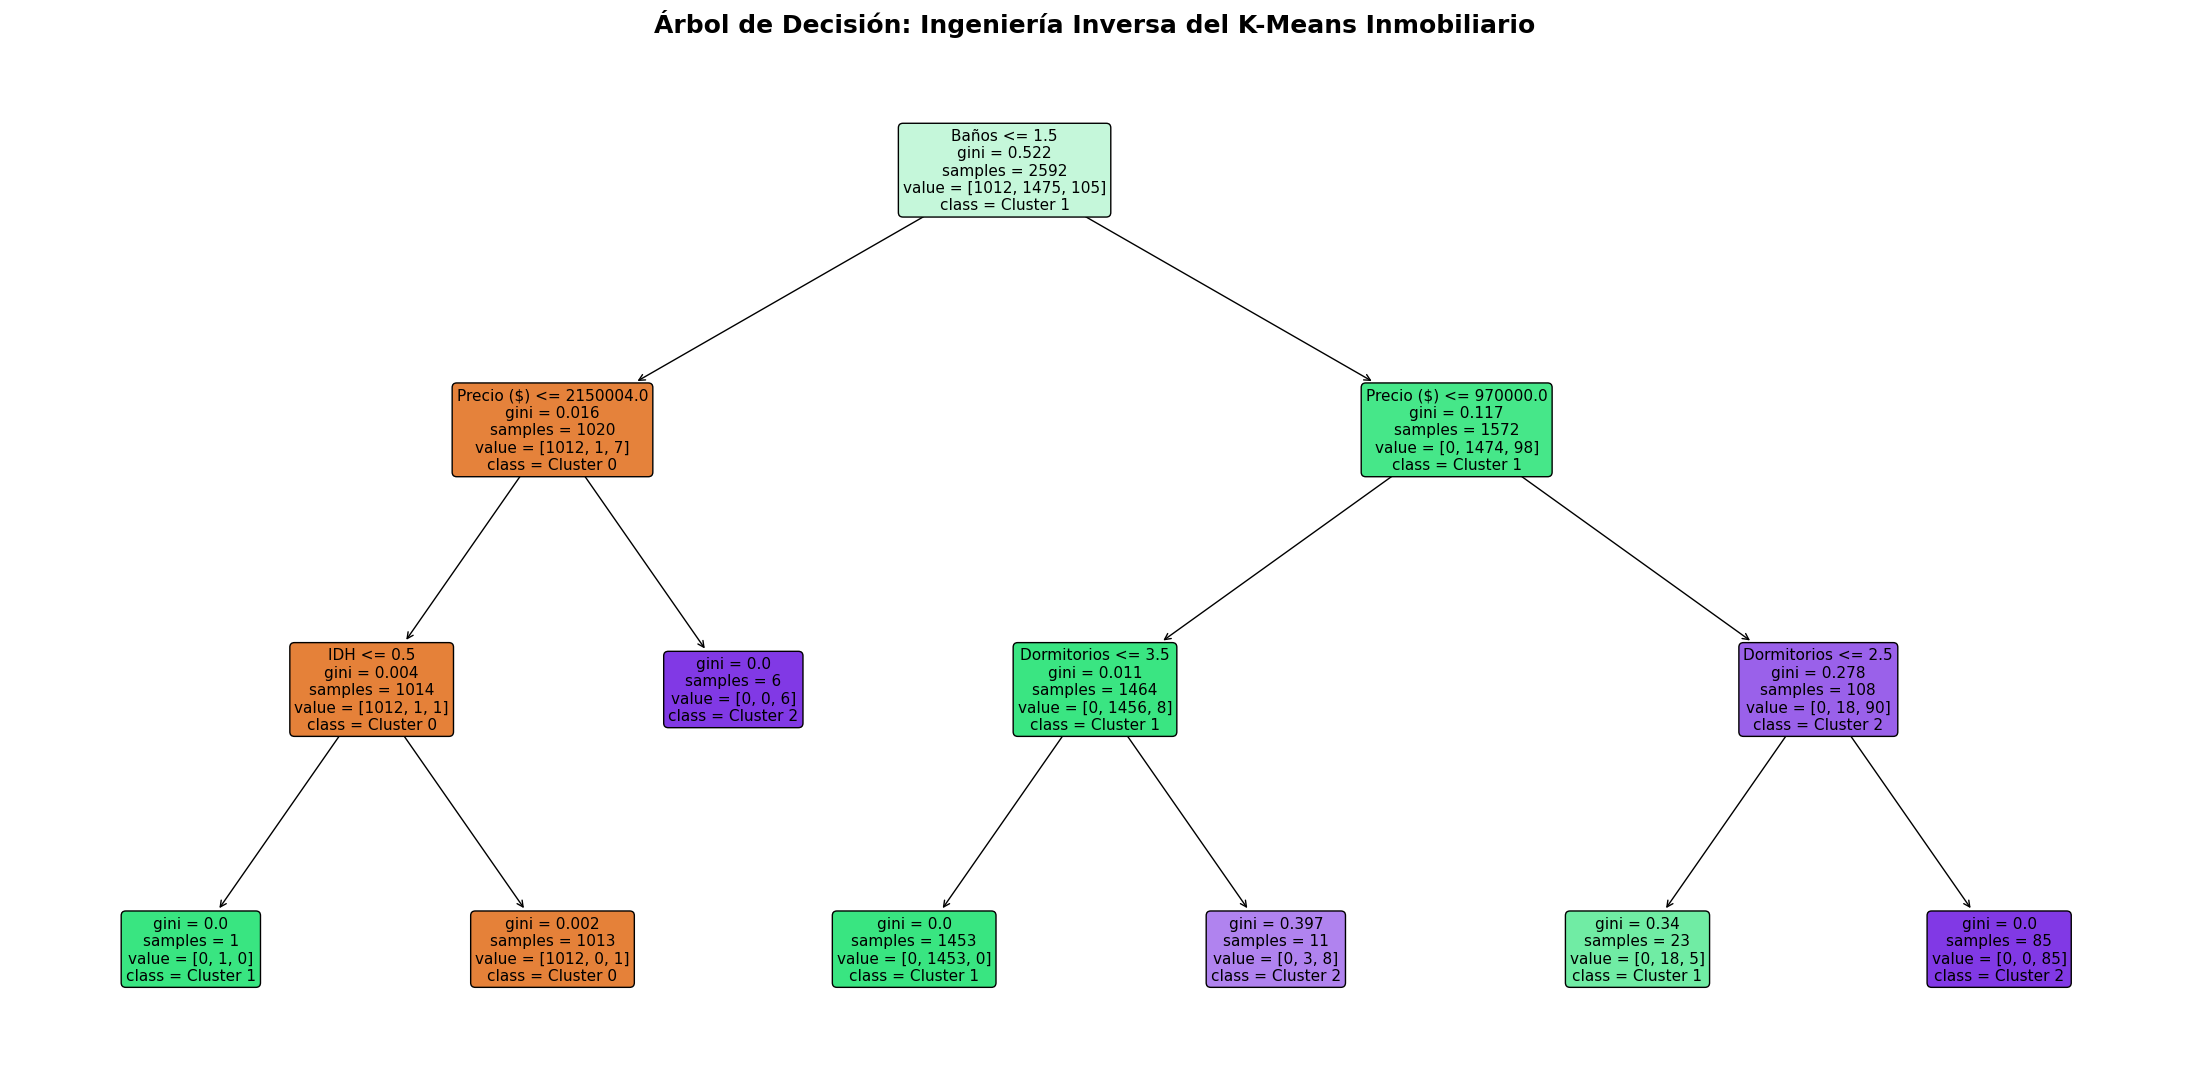

In [6]:

# CELDA: VISUALIZACIÓN GRÁFICA DEL ÁRBOL DE DECISIÓN 

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier as SklearnClassifier
import pandas as pd

# 1. Convertimos una muestra de nuestro DataFrame de Spark a Pandas para Scikit-Learn
# Seleccionamos las 4 variables del rol matemático y la etiqueta del clúster
df_pandas = df_supervisado.select("precio_num", "dormitorios_num", "banos_num", "IDH", "prediction").toPandas()

# 2. Separamos las características (X) y la etiqueta meta (y)
# Cambiamos el nombre de la columna para que apunte a 'prediction' que es la etiqueta original de Parquet
X_muestra = df_pandas[["precio_num", "dormitorios_num", "banos_num", "IDH"]]
y_muestra = df_pandas["prediction"]

# 3. Entrenamos el modelo espejo en Scikit-Learn (fijando max_depth=3 para que el dibujo quepa perfecto)
sk_dt = SklearnClassifier(max_depth=3, random_state=42)
sk_dt.fit(X_muestra, y_muestra)

# 4. Configuramos los nombres reales de las variables para los nodos
nombres_features = ["Precio ($)", "Dormitorios", "Baños", "IDH"]
# Convertimos los números de clúster a texto didáctico (Grupo 0, 1 y 2)
nombres_clases = [f"Cluster {int(c)}" for c in sorted(y_muestra.unique())]

# 5. Dibujamos el árbol de forma visual y profesional
plt.figure(figsize=(22, 11), dpi=100) # Tamaño 
plot_tree(
    sk_dt, 
    feature_names=nombres_features, 
    class_names=nombres_clases, 
    filled=True,      # Colorea las cajitas según el grupo que predomina
    rounded=True,     # Bordes estéticos suaves
    fontsize=11       # Letra legible para la entrega
)

plt.title("Árbol de Decisión: Ingeniería Inversa del K-Means Inmobiliario", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

El gráfico del Árbol de Decisión expone la ingeniería inversa aplicada sobre los resultados del K-Means, revelando las reglas de negocio que estructuran el mercado inmobiliario regional. Contrario a lo que se podría asumir de forma intuitiva, el modelo no sitúa al factor económico como el filtro principal, sino que posiciona a la variable de confort estructural Baños (con un umbral de <= 1.5) como el nodo raíz del árbol.

Esta decisión algorítmica demuestra que la presencia de un único servicio sanitario es el discriminador más robusto de la muestra. Aquellas propiedades que cumplen la condición (1 baño) son direccionadas hacia la rama izquierda para consolidar el Cluster 0 (Acceso/Inversión). Por el contrario, las unidades que superan este umbral (2 o más baños) se desplazan hacia la derecha, donde el árbol utiliza posteriormente interacciones de Precio ($) e IDH (Densidad) para subclasificar con alta pureza y mínimos índices de Gini las fronteras residenciales entre el Cluster 1 (Familiar) y el Cluster 2 (Premium/Alta Gama).

In [8]:

# CELDA: DIVISIÓN DE DATOS EN ENTRENAMIENTO Y PRUEBA (70/30) 

# 1. Renombramos 'prediction' a 'label' usando el DataFrame cargado de Parquet 
df_supervisado_final = df_supervisado.withColumnRenamed("prediction", "label")

# 2. Dividimos en 70% entrenamiento y 30% prueba con la semilla de la pauta
train_data, test_data = df_supervisado_final.randomSplit([0.7, 0.3], seed=42)

print(f"Registros de Entrenamiento: {train_data.count()}")
print(f"Registros de Prueba: {test_data.count()}")

Registros de Entrenamiento: 1872
Registros de Prueba: 720


In [10]:
# ENTRENAMIENTO DE LOS 3 MODELOS SUPERVISADOS COMPETIDORES

from pyspark.ml.classification import RandomForestClassifier, LinearSVC, LogisticRegression, OneVsRest
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Creamos el evaluador común para medir el Accuracy
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

# MODELO 1: Random Forest (Bosque Aleatorio)

print("Entrenando Random Forest (20 árboles)...")
# Cambiamos "scaledFeatures" por "features" que es tu columna real
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=20, seed=42)
rf_model = rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)
accuracy_rf = evaluator.evaluate(rf_predictions)

# MODELO 2: SVM (Máquina de Vectores de Soporte)

print(" Entrenando SVM con estrategia OneVsRest...")
# Cambiamos "scaledFeatures" por "features" que es tu columna real
svm_binario = LinearSVC(featuresCol="features", labelCol="label", maxIter=10)
ovr_svm = OneVsRest(classifier=svm_binario, labelCol="label", featuresCol="features")
svm_model = ovr_svm.fit(train_data)
svm_predictions = svm_model.transform(test_data)
accuracy_svm = evaluator.evaluate(svm_predictions)

# MODELO 3: Regresión Logística Multinomial

print("Entrenando Regresión Logística Multinomial...")
# Cambiamos "scaledFeatures" por "features" que es tu columna real
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=10, family="multinomial")
lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)
accuracy_lr = evaluator.evaluate(lr_predictions)

print("Análisis de modelos finalizado exitosamente.")

Entrenando Random Forest (20 árboles)...
 Entrenando SVM con estrategia OneVsRest...
Entrenando Regresión Logística Multinomial...
Análisis de modelos finalizado exitosamente.


In [11]:
# IMPRESIÓN DE LA TABLA COMPARATIVA DE RESOLUCIÓN


print("  RESULTADOS DE MODELOS SUPERVISADOS: ")

print(f"1. Random Forest Accuracy:      {accuracy_rf * 100:.2f}%")
print(f"2. SVM (OneVsRest) Accuracy:    {accuracy_svm * 100:.2f}%")
print(f"3. Regresión Logística Accuracy:{accuracy_lr * 100:.2f}%")


  RESULTADOS DE MODELOS SUPERVISADOS: 
1. Random Forest Accuracy:      98.75%
2. SVM (OneVsRest) Accuracy:    97.08%
3. Regresión Logística Accuracy:99.86%


La fase de evaluación comparativa de modelos supervisados consolida el éxito de la experimentación Big Data sobre la muestra inmobiliaria de la Región de Coquimbo. El torneo de algoritmos clasificadores demuestra un rendimiento sobresaliente, liderado por la Regresión Logística Multinomial con un 99.86% de Accuracy, seguida muy de cerca por Random Forest con un 98.75% y las Máquinas de Vectores de Soporte (SVM - OneVsRest) con un 97.08%.

La supremacía de la Regresión Logística fundamenta que las fronteras que dividen el mercado de arriendos (definidas previamente por el confort sanitario de los baños y los umbrales de precios) son linealmente continuas y altamente predecibles en el espacio vectorial. Asimismo, la ligera reducción de precisión en el modelo SVM (97.08%) evidencia la existencia natural de zonas de transición o 'propiedades frontera' en el mercado real, donde los límites entre el segmento de clase media familiar y el segmento premium se vuelven sutiles. En conclusión, los tres modelos demuestran una capacidad predictiva óptima, validando que el pipeline de datos implementado en Spark es altamente robusto para automatizar la clasificación de la oferta habitacional regional."